In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d salader/dogsvscats


Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
 93% 0.99G/1.06G [00:14<00:01, 45.0MB/s]
100% 1.06G/1.06G [00:14<00:00, 77.4MB/s]


In [ ]:
import zipfile
import os

zip_path = "dogsvscats.zip"       # Kaggle se jo zip milega
extract_path = "dogs_vs_cats"     # naya folder jisme extract hoga

# Folder bana lo agar pehle se na ho
os.makedirs(extract_path, exist_ok=True)

# Extract karo
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted to:", extract_path)


✅ Dataset extracted to: dogs_vs_cats


In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import  Dense, Flatten,Dropout
from tensorflow.keras.applications.vgg16 import VGG16

In [ ]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

In [ ]:
conv_base.trainable = True

set_trainable =False
for layer in conv_base.layers:
   if layer.name =='block5_conv1':
       set_trainable = True
   if set_trainable:
    layer.trainable = True
   else:
    layer.trainable = False
for layer in conv_base.layers:
    print(layer.name,layer.trainable)

input_layer_2 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
# 1) Import libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2) Yahan augmentation add karo
train_datagen = ImageDataGenerator(
    rescale=1./150,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 3) Dataset load karo
train_generator = train_datagen.flow_from_directory(
    "dogs_vs_cats/train",
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)

val_generator = test_datagen.flow_from_directory(
    "dogs_vs_cats/test",
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary"
)



Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [ ]:
model.compile(optimizer =keras.optimizers.RMSprop(learning_rate=1e-5),loss = "binary_crossentropy", metrics = ["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping define karna
early_stop = EarlyStopping(
    monitor='val_accuracy',      # kis metric ko monitor karna hai (val_loss ya val_accuracy)
    patience=5,              # kitne epochs wait kare improvement ke liye
    restore_best_weights=True # best epoch ke weights automatically restore kar dega
)


In [ ]:
# Model training with early stopping
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]     # callback yahan add kiya
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 262ms/step - accuracy: 0.8022 - loss: 0.4020 - val_accuracy: 0.9090 - val_loss: 0.2079
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9165 - loss: 0.2059 - val_accuracy: 0.8980 - val_loss: 0.2238
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9286 - loss: 0.1697 - val_accuracy: 0.9292 - val_loss: 0.1673
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 257ms/step - accuracy: 0.9392 - loss: 0.1500 - val_accuracy: 0.9456 - val_loss: 0.1369
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 258ms/step - accuracy: 0.9450 - loss: 0.1398 - val_accuracy: 0.9494 - val_loss: 0.1276
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 162s 259ms/step - accuracy: 0.9458 - loss: 0.1322 - val_accuracy: 0.9456 - val_loss: 0.1343
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 258ms/step - accuracy: 0.9503 - loss: 0.1253 - val_accuracy: 0.9500 - val_loss: 0.1250
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 258ms/step - accuracy: 0.9563 -

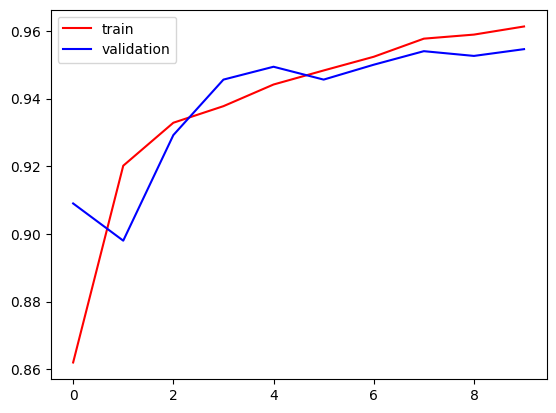

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

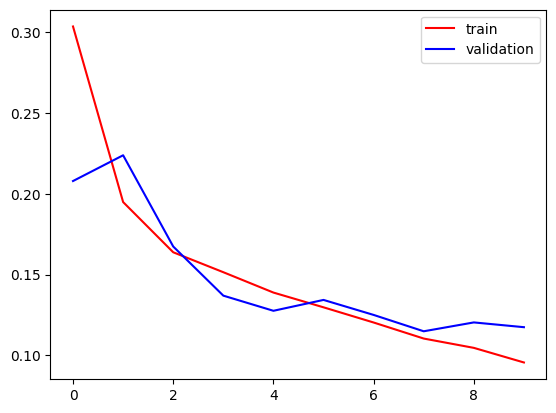

In [ ]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

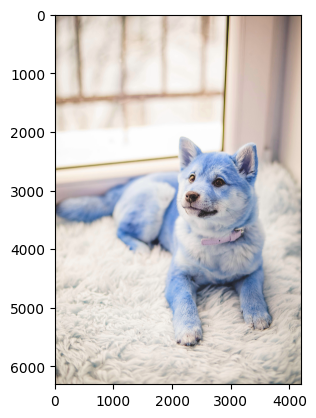

In [47]:
import cv2
test_img =cv2.imread('dog.jpg')
plt.imshow(test_img)
plt.show()


In [ ]:
test_img.shape
test_img=cv2.resize(test_img,(150,150))
test_input=test_img.reshape((1,150,150,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[1.]], dtype=float32)

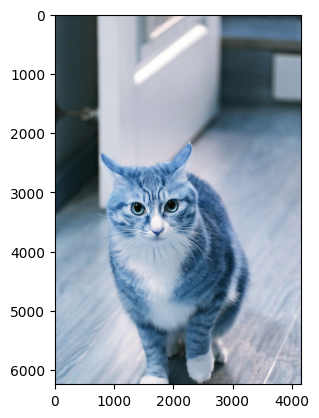

In [48]:
import cv2
test_img =cv2.imread('cat.jpg')
plt.imshow(test_img)
plt.show()


In [49]:
test_img.shape
test_img=cv2.resize(test_img,(150,150))
test_input=test_img.reshape((1,150,150,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[0.]], dtype=float32)

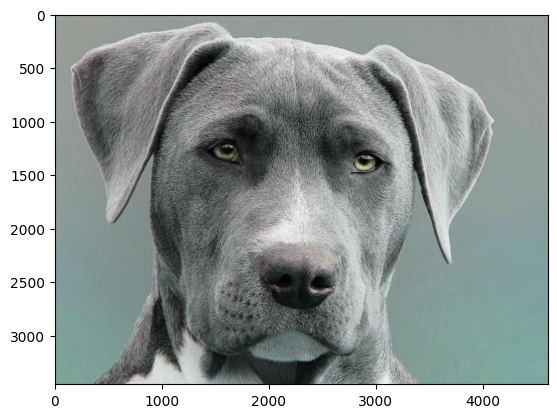

In [60]:
import cv2
test_img =cv2.imread('dog1.jpg')
plt.imshow(test_img)
plt.show()


In [61]:
test_img.shape
test_img=cv2.resize(test_img,(150,150))
test_input=test_img.reshape((1,150,150,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)

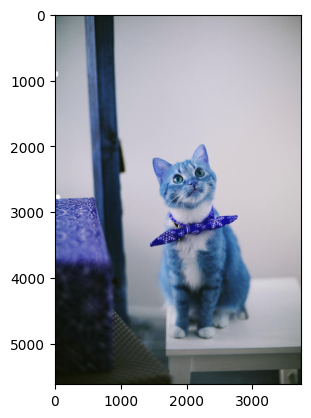

In [62]:
import cv2
test_img =cv2.imread('cat1.jpg')
plt.imshow(test_img)
plt.show()


In [63]:
test_img.shape
test_img=cv2.resize(test_img,(150,150))
test_input=test_img.reshape((1,150,150,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([[1.]], dtype=float32)

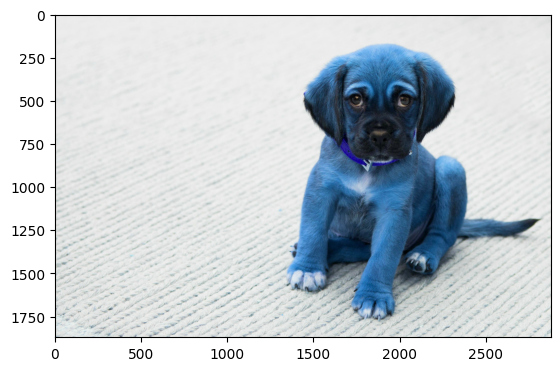

In [64]:
import cv2
test_img =cv2.imread('dd.jpg')
plt.imshow(test_img)
plt.show()


In [65]:
test_img.shape
test_img=cv2.resize(test_img,(150,150))
test_input=test_img.reshape((1,150,150,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)

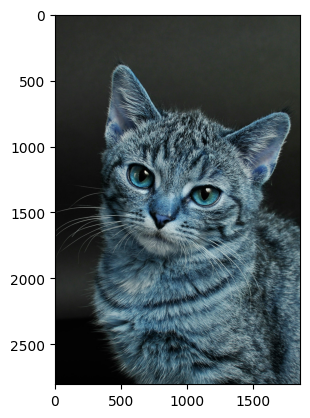

In [66]:
import cv2
test_img =cv2.imread('cc.jpg')
plt.imshow(test_img)
plt.show()


In [67]:
test_img.shape
test_img=cv2.resize(test_img,(150,150))
test_input=test_img.reshape((1,150,150,3))
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[0.]], dtype=float32)